<a href="https://colab.research.google.com/github/anshuman4515/Capstone-project/blob/main/outlier_treatment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df=pd.read_csv('/content/gurgaon_properties_cleaned_v2.csv')

In [4]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,house,signature global park,sohna road,0.85,7589.0,1120.0,Built Up area: 1120 (104.05 sq.m.),3.0,2.0,2.0,1.0,NaN,Under Construction,NaN,1120.0,NaN,0,0,0,0,0,0,15
1,flat,Conscient Heritage Max4.3 ★,sector 102,1.75,9062.0,1931.0,Super Built up area 1931(179.4 sq.m.),3.0,4.0,NaN,16.0,South,Relatively New,1931.0,NaN,NaN,0,1,0,0,0,1,134
2,flat,Raheja Vedaanta3.6 ★,sector 108,0.70,4666.0,1500.0,Built Up area: 1468 (136.38 sq.m.)Carpet area:...,2.0,2.0,1.0,10.0,West,Moderately Old,NaN,1468.0,1150.0,0,0,0,0,0,0,0
3,flat,Alpha Corp GurgaonOne 844.0 ★,sector 84,2.24,6523.0,3434.0,Super Built up area 3434(319.03 sq.m.)Carpet a...,4.0,4.0,3.0,12.0,West,Relatively New,3434.0,NaN,2900.0,0,1,0,0,0,0,20
4,flat,Indiabulls Enigma,sector 110,3.40,10000.0,3400.0,Super Built up area 3400(315.87 sq.m.)Built Up...,4.0,5.0,3.0,10.0,South-West,Relatively New,3400.0,3000.0,2800.0,0,1,0,0,0,0,152


In [5]:
df.shape

(3803, 23)

In [6]:
df.duplicated().sum()

np.int64(125)

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df.shape

(3678, 23)

In [9]:
df.columns

Index(['property_type', 'society', 'sector', 'price', 'price_per_sqft', 'area',
       'areaWithType', 'bedRoom', 'bathroom', 'balcony', 'floorNum', 'facing',
       'agePossession', 'super_built_up_area', 'built_up_area', 'carpet_area',
       'study room', 'servant room', 'store room', 'pooja room', 'others',
       'furnishing_type', 'luxury_score'],
      dtype='object')

/tmp/ipykernel_436/2797181776.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price'])


<Axes: xlabel='price', ylabel='Density'>

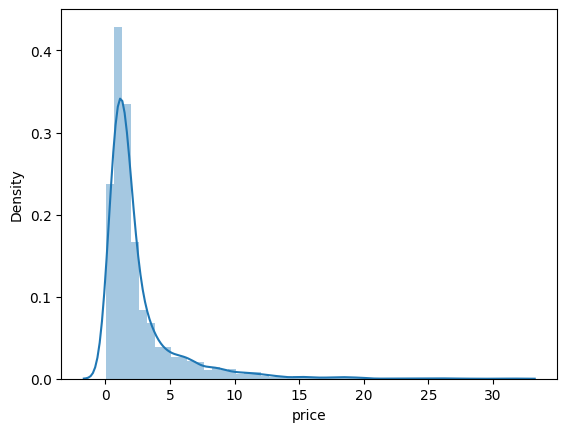

In [10]:
# outliers on the basis of price column
sns.distplot(df['price'])

<Axes: xlabel='price'>

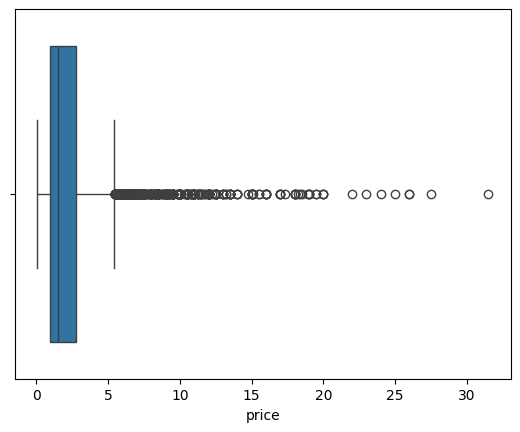

In [11]:
sns.boxplot(x=df['price'])

In [12]:
# Calculate the IQR for the 'price' column
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]

# Displaying the number of outliers and some statistics
num_outliers = outliers.shape[0]
outliers_price_stats = outliers['price'].describe()

num_outliers, outliers_price_stats

(425,
 count    425.000000
 mean       9.235624
 std        4.065259
 min        5.460000
 25%        6.460000
 50%        8.000000
 75%       10.750000
 max       31.500000
 Name: price, dtype: float64)

In [13]:
outliers.sort_values('price',ascending=False).head(20)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3227,house,arjun marg/ sector- 26 phase- 1/ golf course road,sector 26,31.50,35000.0,9000.0,Plot area 1000(836.13 sq.m.),7.0,9.0,NaN,3.0,North-East,Moderately Old,NaN,9000.0,NaN,1,1,1,1,0,2,74
3163,house,independent,sector 43,27.50,24366.0,11286.0,Plot area 1254(1048.5 sq.m.),6.0,7.0,NaN,3.0,North-East,Relatively New,NaN,11286.0,NaN,1,1,0,1,1,1,42
2387,house,dlf city plots,sector 26,26.00,57206.0,4545.0,Plot area 505(422.24 sq.m.),6.0,7.0,NaN,2.0,North-East,New Property,NaN,4545.0,NaN,1,1,0,1,1,1,138
1097,house,independent,sector 26,26.00,82540.0,3150.0,Plot area 402(336.12 sq.m.)Built Up area: 400 ...,16.0,16.0,NaN,4.0,North-West,New Property,NaN,400.0,350.0,1,1,1,1,0,2,72
2763,house,suncity township,sector 54,25.00,31111.0,8036.0,Plot area 1000(836.13 sq.m.),4.0,4.0,NaN,2.0,North,Moderately Old,NaN,1000.0,NaN,1,1,1,1,0,0,0
3640,house,emaar the palm springs,sector 54,24.00,600000.0,400.0,Plot area 400(37.16 sq.m.),5.0,5.0,2.0,1.0,North-East,Old Property,NaN,400.0,NaN,1,1,0,1,0,1,122
3788,house,independent,sector 26,23.00,25556.0,9000.0,Plot area 1000(836.13 sq.m.),4.0,4.0,NaN,2.0,South-West,Relatively New,NaN,9000.0,NaN,1,1,1,1,0,1,145
822,house,vipul tatvam villa,sector 48,22.00,26667.0,8250.0,Plot area 1000(836.13 sq.m.),5.0,6.0,3.0,3.0,NaN,Moderately Old,NaN,1000.0,NaN,0,1,0,0,0,0,54
1974,house,independent,sector 26,20.00,44444.0,4500.0,Plot area 500(418.06 sq.m.),5.0,7.0,NaN,3.0,West,Relatively New,NaN,4500.0,NaN,0,1,0,1,0,2,97
968,house,luxury dlf city floors,sector 26,20.00,48889.0,4091.0,Plot area 500(418.06 sq.m.),16.0,16.0,NaN,4.0,NaN,New Property,NaN,500.0,NaN,0,1,0,0,0,1,31


price_per_sqft

/tmp/ipykernel_436/2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

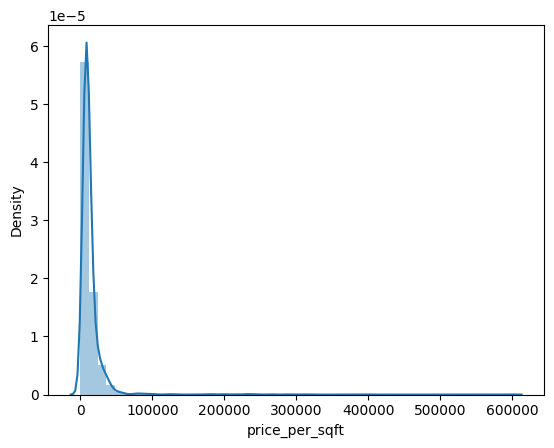

In [14]:
sns.distplot(df['price_per_sqft'])

<Axes: xlabel='price_per_sqft'>

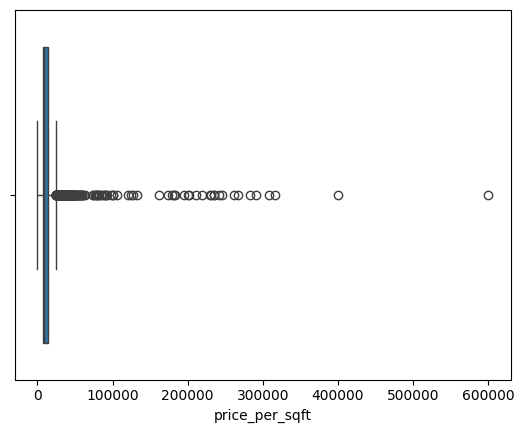

In [15]:
sns.boxplot(x=df['price_per_sqft'])

In [16]:
# Calculate the IQR for the 'price' column
Q1 = df['price_per_sqft'].quantile(0.25)
Q3 = df['price_per_sqft'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers_sqft = df[(df['price_per_sqft'] < lower_bound) | (df['price_per_sqft'] > upper_bound)]

# Displaying the number of outliers and some statistics
num_outliers = outliers_sqft.shape[0]
outliers_sqft_stats = outliers_sqft['price_per_sqft'].describe()

num_outliers, outliers_sqft_stats

(354,
 count       354.000000
 mean      52592.612994
 std       61150.458507
 min       24489.000000
 25%       28208.250000
 50%       33368.500000
 75%       41982.250000
 max      600000.000000
 Name: price_per_sqft, dtype: float64)

In [17]:
outliers_sqft['area'] = outliers_sqft['area'].apply(lambda x:x*9 if x<1000 else x)

/tmp/ipykernel_436/205471443.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_sqft['area'] = outliers_sqft['area'].apply(lambda x:x*9 if x<1000 else x)


In [18]:
outliers_sqft['price_per_sqft'] = round((outliers_sqft['price']*10000000)/outliers_sqft['area'])

/tmp/ipykernel_436/3686006548.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_sqft['price_per_sqft'] = round((outliers_sqft['price']*10000000)/outliers_sqft['area'])


In [19]:
outliers_sqft['price_per_sqft'].describe()

,price_per_sqft
count,354.000000
mean,29357.906780
std,12403.077309
min,2723.000000
25%,25562.000000
50%,29870.500000
75%,35549.500000
max,82540.000000


In [20]:
df.update(outliers_sqft)

/tmp/ipykernel_436/2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

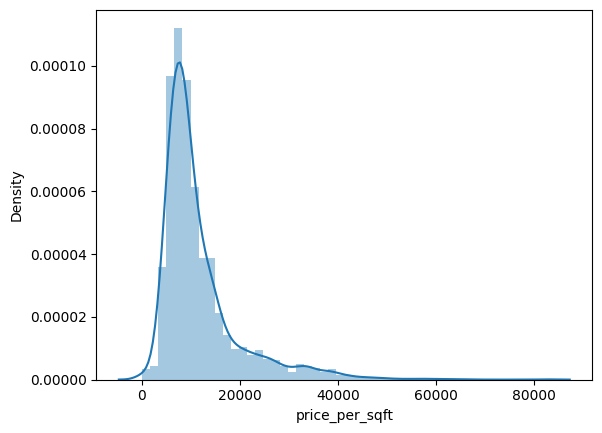

In [21]:
sns.distplot(df['price_per_sqft'])

<Axes: xlabel='price_per_sqft'>

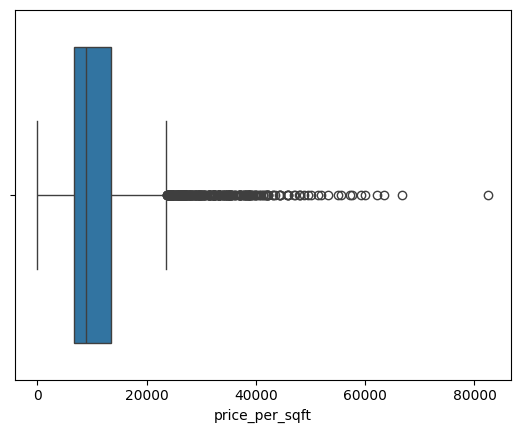

In [22]:
sns.boxplot(x=df['price_per_sqft'])

In [23]:
df[df['price_per_sqft']>50000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
803,house,independent,sector 26,14.75,51864.0,2844.0,Plot area 316(264.22 sq.m.),16.0,20.0,NaN,4.0,East,New Property,NaN,2844.0,NaN,1,1,1,1,0,1,153
1074,house,nul,sector 28,12.50,51440.0,2430.0,Plot area 270(225.75 sq.m.),16.0,17.0,NaN,4.0,South,Relatively New,NaN,2430.0,NaN,1,1,0,1,1,2,137
1097,house,independent,sector 26,26.00,82540.0,3150.0,Plot area 402(336.12 sq.m.)Built Up area: 400 ...,16.0,16.0,NaN,4.0,North-West,New Property,NaN,400.0,350.0,1,1,1,1,0,2,72
1487,house,emaar mgf marbella,sector 66,18.00,55556.0,3240.0,Plot area 360(301.01 sq.m.),4.0,4.0,NaN,3.0,East,Moderately Old,NaN,3240.0,NaN,1,1,0,1,0,2,75
1702,house,emaar the palm springs,sector 54,14.00,62222.0,2250.0,Plot area 250(209.03 sq.m.),4.0,5.0,NaN,2.0,North,Old Property,NaN,2250.0,NaN,1,1,0,0,0,1,160
1982,house,independent,sector 25,16.00,59259.0,2700.0,Plot area 350(292.64 sq.m.)Built Up area: 325 ...,16.0,16.0,NaN,4.0,West,New Property,NaN,325.0,300.0,1,1,1,1,0,2,72
2376,house,unitech escape,sector 50,10.80,60000.0,1800.0,Plot area 290(242.48 sq.m.)Built Up area: 250 ...,4.0,4.0,3.0,2.0,North,Relatively New,NaN,250.0,200.0,1,1,1,1,0,1,103
2387,house,dlf city plots,sector 26,26.00,57206.0,4545.0,Plot area 505(422.24 sq.m.),6.0,7.0,NaN,2.0,North-East,New Property,NaN,4545.0,NaN,1,1,0,1,1,1,138
2414,flat,Unitech Vistas,sector 70,9.00,57508.0,1565.0,Built Up area: 1565 (145.39 sq.m.),3.0,3.0,NaN,7.0,NaN,Undefined,NaN,1565.0,NaN,0,0,0,0,0,0,0
2900,house,cloudnine cottages,sohna road road,5.50,55000.0,1000.0,Plot area 1000(92.9 sq.m.),3.0,3.0,NaN,1.0,NaN,Moderately Old,NaN,1000.0,NaN,0,0,0,0,0,0,0


In [24]:
df = df[df['price_per_sqft'] <= 50000]

<Axes: xlabel='price_per_sqft'>

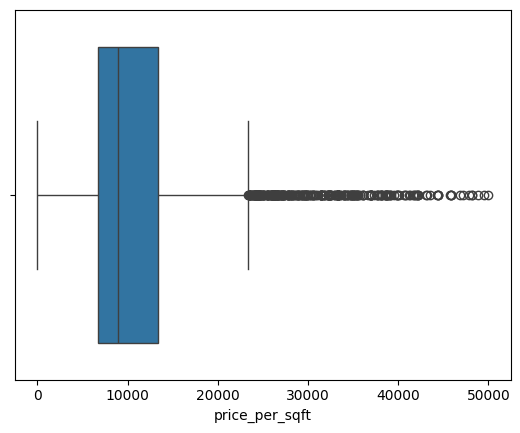

In [25]:
sns.boxplot(x=df['price_per_sqft'])

Area

/tmp/ipykernel_436/91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

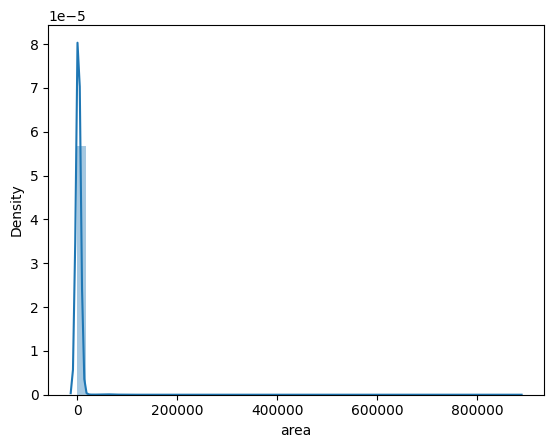

In [26]:
sns.distplot(df['area'])

<Axes: xlabel='area'>

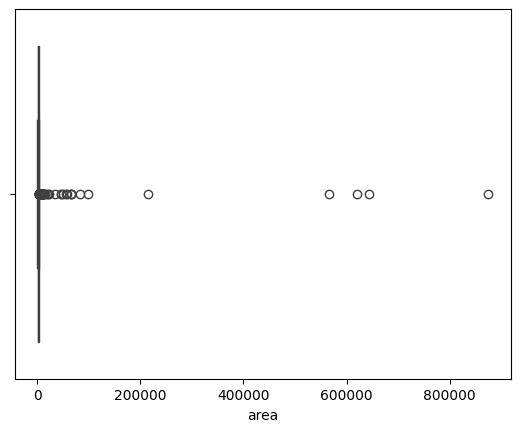

In [27]:
sns.boxplot(x=df['area'])

In [28]:
df['area'].describe()

,area
count,3648.000000
mean,2947.543311
std,23205.014620
min,145.000000
25%,1262.000000
50%,1750.000000
75%,2350.000000
max,875000.000000


In [29]:
df[df['area'] > 100000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
50,flat,Ramsons Kshitij3.7 ★,sector 95,0.31,5.0,620000.0,Carpet area: 607936 (56479.1 sq.m.),2.0,2.0,1.0,1.0,North-East,Relatively New,NaN,NaN,607936.0,1,0,0,0,1,0,65
528,flat,HCBS Sports Ville3.6 ★,sohna road,0.35,4.0,875000.0,Built Up area: 737147 (68483.2 sq.m.),2.0,2.0,2.0,8.0,NaN,Relatively New,NaN,737147.0,NaN,0,0,0,0,0,2,44
1628,house,independent,sector 50,5.00,232.0,215517.0,Plot area 2(1011.71 sq.m.),6.0,5.0,NaN,2.0,NaN,New Property,NaN,2.0,NaN,1,1,0,1,1,1,0
2063,flat,Signature The Roselia3.6 ★,sector 95,0.45,7.0,642857.0,Carpet area: 569243 (52884.41 sq.m.),2.0,2.0,2.0,2.0,South-West,New Property,NaN,NaN,569243.0,0,0,0,0,0,0,76
3368,flat,Signature Global Solera 2,sector 107,0.51,9.0,566667.0,Carpet area: 514396 (47788.95 sq.m.),2.0,2.0,1.0,3.0,North,New Property,NaN,NaN,514396.0,0,0,0,0,0,0,44


In [30]:
df = df[df['area'] < 100000]

/tmp/ipykernel_436/91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

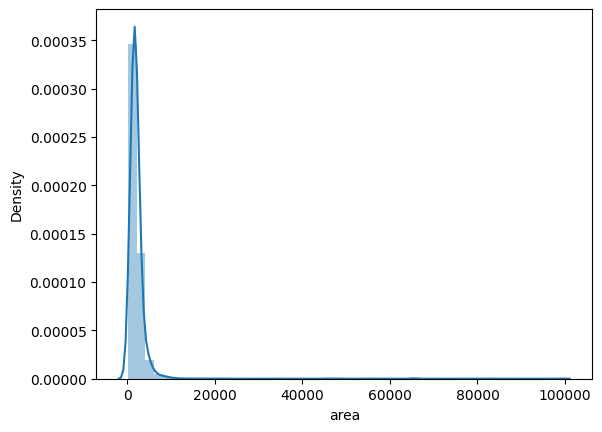

In [31]:
sns.distplot(df['area'])

<Axes: xlabel='area'>

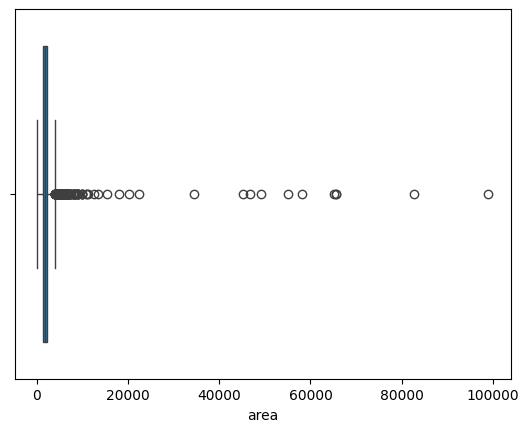

In [32]:
sns.boxplot(x=df['area'])

In [33]:
df[df['area'] > 10000].sort_values('area',ascending=False)

# 818, 1796, 1123, 2, 2356, 115, 3649, 2503, 1471

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2232,house,independent,sector 26,18.40,1859.0,98978.0,Plot area 502(419.74 sq.m.)Carpet area: 11000 ...,6.0,8.0,NaN,4.0,South,Relatively New,NaN,NaN,11000.00,0,1,1,1,0,1,60
1771,house,ganpati heights apartment,sector 13,1.25,151.0,82781.0,Plot area 115(7692.86 sq.m.),10.0,6.0,2.0,3.0,South-East,Old Property,NaN,115.0,NaN,0,0,0,0,1,0,7
728,flat,ROF Ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64529 (5994.94 sq.m.),2.0,2.0,2.0,10.0,East,New Property,NaN,NaN,64529.00,1,0,0,0,0,0,15
2832,flat,ROF Ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64412 (5984.07 sq.m.),3.0,2.0,1.0,12.0,North,Relatively New,NaN,NaN,64412.00,0,0,0,0,0,0,51
249,house,dlf city plot phase 4,sector 28,13.00,1992.0,65261.0,Carpet area: 7250 (6061.92 sq.m.),10.0,10.0,NaN,1.0,NaN,Undefined,NaN,NaN,7250.00,0,0,0,0,0,0,0
2025,flat,Pyramid Elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2.0,2.0,1.0,0.0,NaN,Under Construction,NaN,NaN,58141.00,0,0,0,0,0,0,15
2791,flat,ROF Ananda,sector 95,0.33,60.0,55000.0,Carpet area: 54917 (5101.96 sq.m.),2.0,2.0,1.0,13.0,South-West,Relatively New,NaN,NaN,54917.00,0,0,0,0,0,0,37
1555,flat,Signature The Serenas,sohna road,0.28,57.0,49123.0,Carpet area: 48811 (4534.69 sq.m.),1.0,1.0,2.0,1.0,North-West,Relatively New,NaN,NaN,48811.00,1,0,0,0,0,0,37
1625,house,independent,sector 25,7.30,1560.0,46795.0,Plot area 215(179.77 sq.m.)Built Up area: 5800...,9.0,9.0,2.0,3.0,North-West,Relatively New,NaN,5800.0,5200.00,0,1,1,0,0,1,109
2083,flat,Ramsons Kshitij3.7 ★,sector 95,0.24,53.0,45283.0,Carpet area: 45966 (4270.38 sq.m.),2.0,2.0,1.0,10.0,North-West,Relatively New,NaN,NaN,45966.00,0,0,0,0,1,0,33


In [34]:
df.drop(index=[818, 1796, 1123, 2, 2356, 115, 3649, 2503, 1471], inplace=True)

In [35]:
df[df['area'] > 10000].sort_values('area',ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2232,house,independent,sector 26,18.40,1859.0,98978.0,Plot area 502(419.74 sq.m.)Carpet area: 11000 ...,6.0,8.0,NaN,4.0,South,Relatively New,NaN,NaN,11000.00,0,1,1,1,0,1,60
1771,house,ganpati heights apartment,sector 13,1.25,151.0,82781.0,Plot area 115(7692.86 sq.m.),10.0,6.0,2.0,3.0,South-East,Old Property,NaN,115.0,NaN,0,0,0,0,1,0,7
728,flat,ROF Ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64529 (5994.94 sq.m.),2.0,2.0,2.0,10.0,East,New Property,NaN,NaN,64529.00,1,0,0,0,0,0,15
2832,flat,ROF Ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64412 (5984.07 sq.m.),3.0,2.0,1.0,12.0,North,Relatively New,NaN,NaN,64412.00,0,0,0,0,0,0,51
249,house,dlf city plot phase 4,sector 28,13.00,1992.0,65261.0,Carpet area: 7250 (6061.92 sq.m.),10.0,10.0,NaN,1.0,NaN,Undefined,NaN,NaN,7250.00,0,0,0,0,0,0,0
2025,flat,Pyramid Elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2.0,2.0,1.0,0.0,NaN,Under Construction,NaN,NaN,58141.00,0,0,0,0,0,0,15
2791,flat,ROF Ananda,sector 95,0.33,60.0,55000.0,Carpet area: 54917 (5101.96 sq.m.),2.0,2.0,1.0,13.0,South-West,Relatively New,NaN,NaN,54917.00,0,0,0,0,0,0,37
1555,flat,Signature The Serenas,sohna road,0.28,57.0,49123.0,Carpet area: 48811 (4534.69 sq.m.),1.0,1.0,2.0,1.0,North-West,Relatively New,NaN,NaN,48811.00,1,0,0,0,0,0,37
1625,house,independent,sector 25,7.30,1560.0,46795.0,Plot area 215(179.77 sq.m.)Built Up area: 5800...,9.0,9.0,2.0,3.0,North-West,Relatively New,NaN,5800.0,5200.00,0,1,1,0,0,1,109
2083,flat,Ramsons Kshitij3.7 ★,sector 95,0.24,53.0,45283.0,Carpet area: 45966 (4270.38 sq.m.),2.0,2.0,1.0,10.0,North-West,Relatively New,NaN,NaN,45966.00,0,0,0,0,1,0,33


In [36]:
df.loc[48,'area'] = 115*9
df.loc[300,'area'] = 7250
df.loc[2666,'area'] = 5800
df.loc[1358,'area'] = 2660
df.loc[3195,'area'] = 2850
df.loc[2131,'area'] = 1812
df.loc[3088,'area'] = 2160
df.loc[3444,'area'] = 1175

/tmp/ipykernel_436/91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

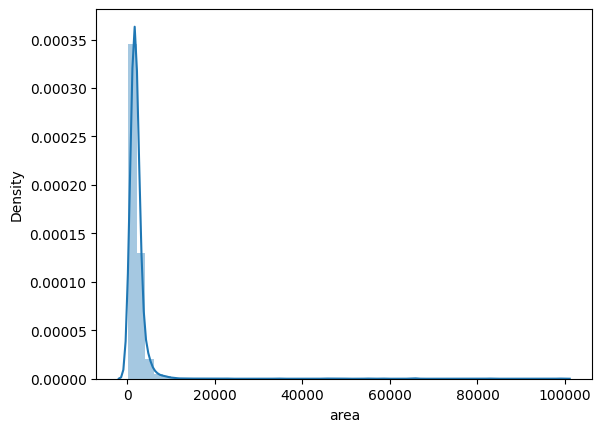

In [37]:
sns.distplot(df['area'])

<Axes: xlabel='area'>

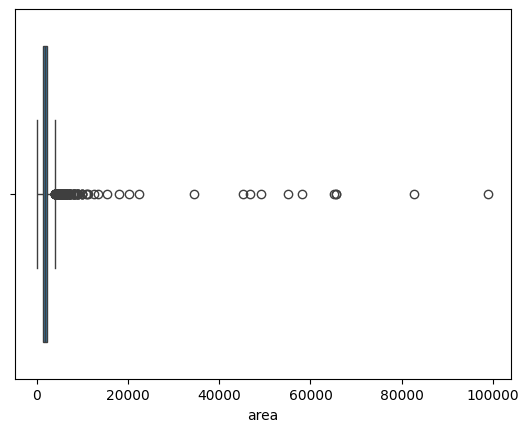

In [38]:
sns.boxplot(x=df['area'])

In [39]:
df['area'].describe()

,area
count,3636.000000
mean,2154.467547
std,3627.920325
min,145.000000
25%,1262.000000
50%,1750.000000
75%,2350.000000
max,98978.000000


Bedroom

/tmp/ipykernel_436/1691983684.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bedRoom'])


<Axes: xlabel='bedRoom', ylabel='Density'>

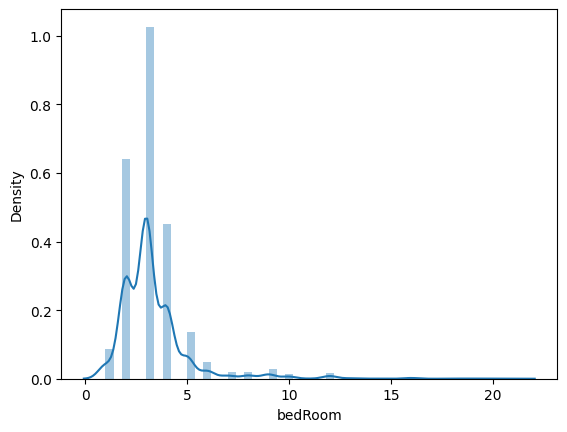

In [40]:
sns.distplot(df['bedRoom'])

<Axes: xlabel='bedRoom'>

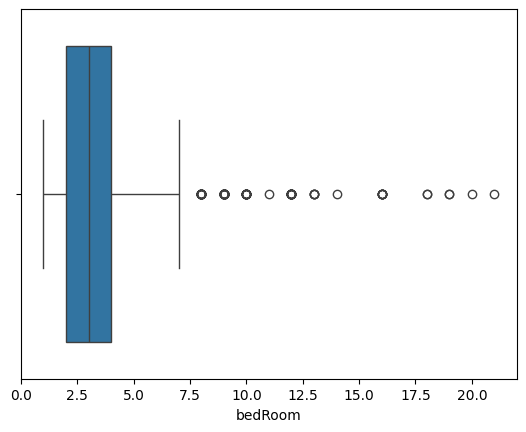

In [41]:
sns.boxplot(x=df['bedRoom'])

In [42]:
df['bedRoom'].describe()

,bedRoom
count,3634.000000
mean,3.330490
std,1.825446
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,21.000000


In [43]:
df[df['bedRoom'] > 10].sort_values('bedRoom',ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1073,house,independent,sector 54,5.00,43066.0,1161.0,Plot area 129(107.86 sq.m.),21.0,21.0,NaN,5.0,North,Relatively New,NaN,1161.0,NaN,0.0,1.0,0.0,0.0,0.0,2.0,49.0
878,house,independent,sector 43,4.50,39062.0,1152.0,Plot area 128(107.02 sq.m.),20.0,20.0,NaN,4.0,East,Relatively New,NaN,1152.0,NaN,0.0,1.0,0.0,0.0,0.0,2.0,22.0
2301,house,independent,sector 17a,3.93,24214.0,1623.0,Plot area 1623(150.78 sq.m.)Built Up area: 162...,19.0,17.0,3.0,4.0,North-West,Relatively New,NaN,1622.0,NaN,1.0,1.0,1.0,1.0,0.0,0.0,74.0
3777,house,independent,sector 17a,3.87,5160.0,7500.0,Plot area 1623(150.78 sq.m.)Built Up area: 750...,19.0,17.0,NaN,5.0,North-West,Relatively New,NaN,7500.0,NaN,1.0,0.0,1.0,0.0,0.0,0.0,68.0
2411,house,independent,sector 54,5.50,38194.0,1440.0,Plot area 160(133.78 sq.m.),18.0,18.0,NaN,4.0,South-West,Relatively New,NaN,1440.0,NaN,0.0,1.0,0.0,0.0,0.0,2.0,70.0
3152,house,private house,sector 55,7.05,46906.0,1503.0,Plot area 167(139.63 sq.m.),18.0,18.0,NaN,4.0,North-East,Relatively New,NaN,1503.0,NaN,0.0,0.0,0.0,0.0,1.0,2.0,57.0
2575,house,dlf city plots,sector 26,20.00,44267.0,4518.0,Plot area 502(419.74 sq.m.),16.0,20.0,NaN,4.0,North-East,New Property,NaN,4518.0,NaN,1.0,1.0,1.0,1.0,0.0,1.0,153.0
2259,house,independent,sector 43,13.50,50000.0,2700.0,Plot area 300(250.84 sq.m.),16.0,16.0,NaN,4.0,North-West,Relatively New,NaN,2700.0,NaN,1.0,1.0,0.0,1.0,1.0,0.0,41.0
1543,house,independent,sushant lok phase 2,9.19,34037.0,2700.0,Plot area 300(250.84 sq.m.),16.0,18.0,2.0,4.0,West,New Property,NaN,2700.0,NaN,0.0,1.0,0.0,1.0,0.0,1.0,49.0
1018,house,independent,sector 56,12.39,45889.0,2700.0,Plot area 300(250.84 sq.m.),16.0,18.0,NaN,4.0,North-East,New Property,NaN,2700.0,NaN,0.0,1.0,0.0,1.0,0.0,1.0,49.0


In [44]:
df = df[df['bedRoom'] <= 10]

In [45]:
df.shape

(3590, 23)

/tmp/ipykernel_436/1691983684.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bedRoom'])


<Axes: xlabel='bedRoom', ylabel='Density'>

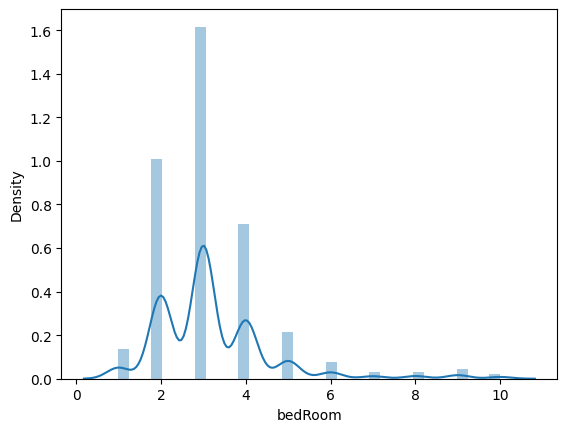

In [46]:
sns.distplot(df['bedRoom'])

/tmp/ipykernel_436/1691983684.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bedRoom'])


<Axes: xlabel='bedRoom', ylabel='Density'>

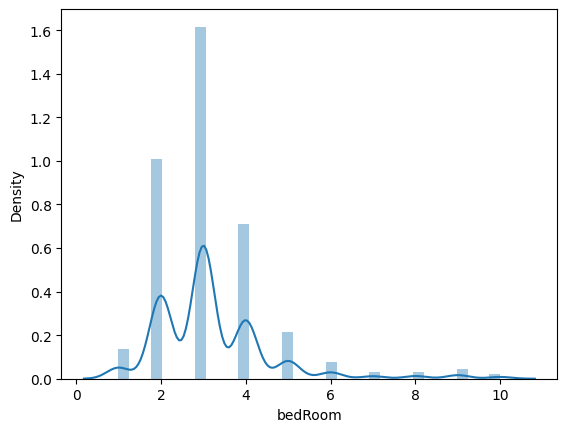

In [47]:
sns.distplot(df['bedRoom'])

In [48]:
df['bedRoom'].describe()

,bedRoom
count,3590.000000
mean,3.203064
std,1.395268
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,10.000000


Bathroom

/tmp/ipykernel_436/2904465235.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bathroom'])


<Axes: xlabel='bathroom', ylabel='Density'>

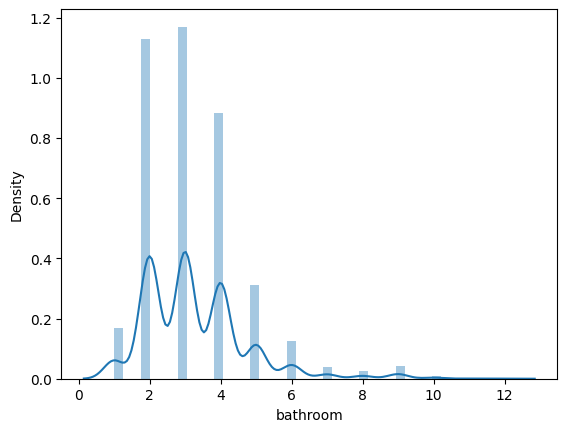

In [49]:
sns.distplot(df['bathroom'])

<Axes: xlabel='bathroom'>

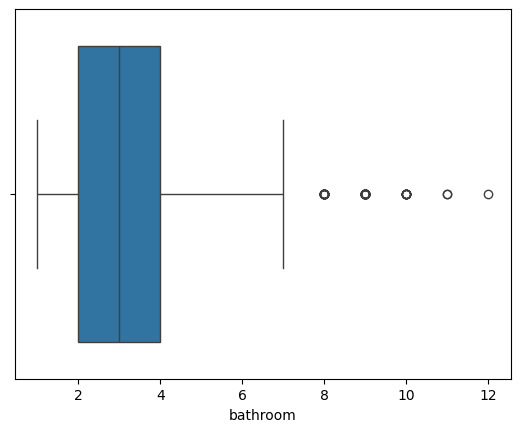

In [50]:
sns.boxplot(x=df['bathroom'])

In [51]:
df[df['bathroom'] > 10].sort_values('bathroom',ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
580,house,adani brahma samsara,sector 60,18.02,28200.0,6390.0,Built Up area: 6390 (593.65 sq.m.),9.0,12.0,NaN,3.0,North-East,Relatively New,NaN,6390.0,NaN,0.0,1.0,0.0,0.0,0.0,1.0,146.0
1076,house,independent,sector 39,7.00,10000.0,7000.0,Plot area 350(32.52 sq.m.)Built Up area: 7000 ...,10.0,11.0,NaN,4.0,South-East,Relatively New,NaN,7000.0,NaN,0.0,0.0,0.0,1.0,0.0,2.0,38.0
2170,house,independent,sector 24,11.00,28902.0,3806.0,Plot area 3806.45(353.63 sq.m.)Built Up area: ...,8.0,11.0,NaN,3.0,East,Old Property,NaN,5000.0,NaN,1.0,1.0,0.0,1.0,1.0,1.0,39.0


super built up area

/tmp/ipykernel_436/4184943455.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['super_built_up_area'])


<Axes: xlabel='super_built_up_area', ylabel='Density'>

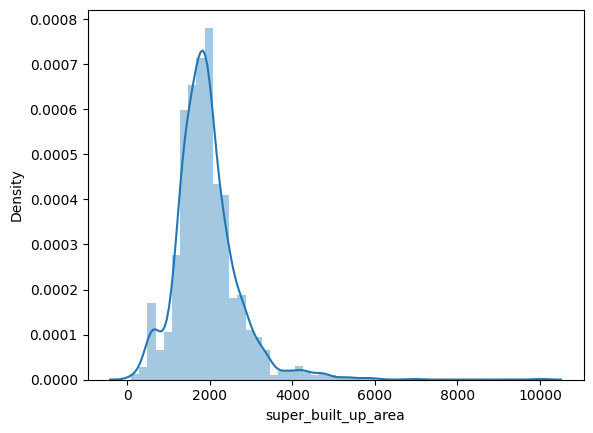

In [52]:
sns.distplot(df['super_built_up_area'])

<Axes: xlabel='super_built_up_area'>

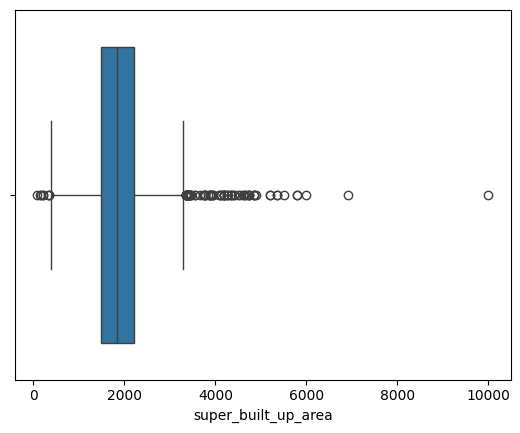

In [53]:
sns.boxplot(x=df['super_built_up_area'])

In [54]:
df['super_built_up_area'].describe()

,super_built_up_area
count,1872.000000
mean,1924.674439
std,763.833183
min,89.000000
25%,1479.750000
50%,1828.000000
75%,2215.000000
max,10000.000000


In [55]:
df[df['super_built_up_area'] > 6000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2602,flat,Krrish Provence Estate,gwal pahari,7.5,7500.0,10000.0,Super Built up area 10000(929.03 sq.m.),5.0,6.0,NaN,23.0,North-East,Relatively New,10000.0,NaN,NaN,0.0,1.0,0.0,1.0,1.0,0.0,49.0
3547,flat,Bestech Park View Grand Spa4.3 ★,sector 81,4.7,6786.0,6926.0,Super Built up area 6926(643.45 sq.m.),4.0,4.0,NaN,19.0,North,Relatively New,6926.0,NaN,NaN,0.0,1.0,0.0,0.0,0.0,1.0,140.0


built up area

/tmp/ipykernel_436/2846228355.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['built_up_area'])


<Axes: xlabel='built_up_area', ylabel='Density'>

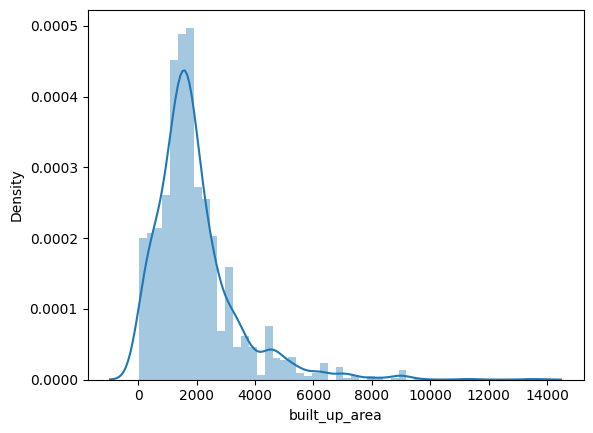

In [56]:
sns.distplot(df['built_up_area'])


<Axes: xlabel='built_up_area'>

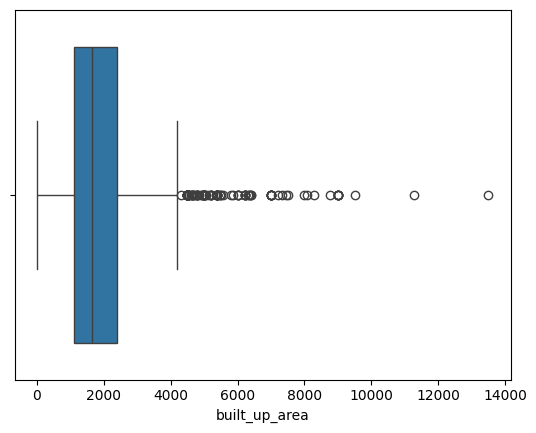

In [57]:
sns.boxplot(x=df['built_up_area'])

In [58]:
df[df['built_up_area'] > 10000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2471,house,independent,sector 4,0.85,630.0,13492.0,Plot area 1500(1254.19 sq.m.),3.0,3.0,1.0,1.0,North,Relatively New,NaN,13500.0,NaN,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3163,house,independent,sector 43,27.50,24366.0,11286.0,Plot area 1254(1048.5 sq.m.),6.0,7.0,NaN,3.0,North-East,Relatively New,NaN,11286.0,NaN,1.0,1.0,0.0,1.0,1.0,1.0,42.0


carpet area

/tmp/ipykernel_436/3905767603.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['carpet_area'])


<Axes: xlabel='carpet_area', ylabel='Density'>

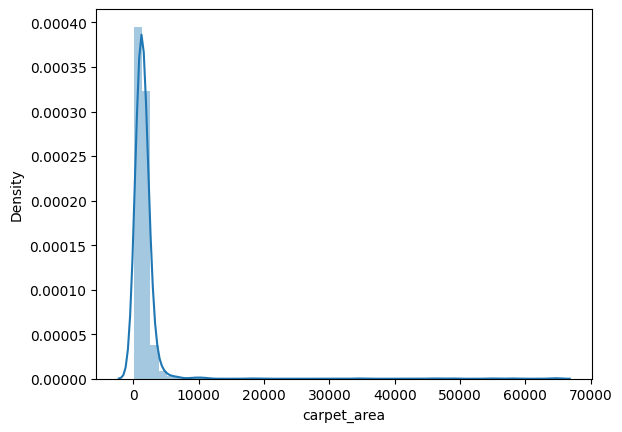

In [59]:
sns.distplot(df['carpet_area'])

<Axes: xlabel='carpet_area'>

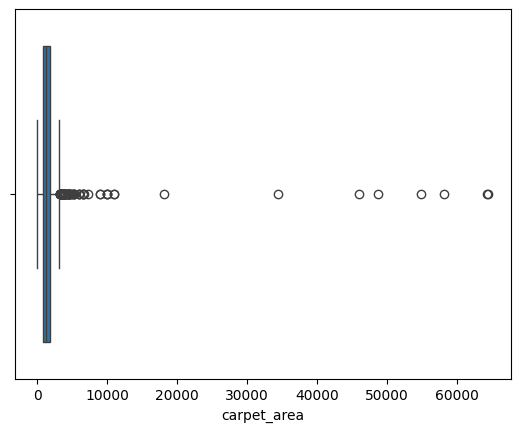

In [60]:
sns.boxplot(x=df['carpet_area'])

In [61]:
df[df['carpet_area'] > 10000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
214,flat,ROF Ananda,sector 95,0.21,61.0,34426.0,Carpet area: 34401 (3195.96 sq.m.),1.0,1.0,1.0,13.0,North,Relatively New,NaN,NaN,34401.0,0.0,0.0,0.0,0.0,0.0,0.0,68.0
728,flat,ROF Ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64529 (5994.94 sq.m.),2.0,2.0,2.0,10.0,East,New Property,NaN,NaN,64529.0,1.0,0.0,0.0,0.0,0.0,0.0,15.0
1000,flat,M3M Golfestate4.4 ★,sector 65,13.20,12000.0,11000.0,Carpet area: 11000 (1021.93 sq.m.),4.0,4.0,3.0,13.0,North,Moderately Old,NaN,NaN,11000.0,0.0,1.0,0.0,0.0,0.0,0.0,60.0
1555,flat,Signature The Serenas,sohna road,0.28,57.0,49123.0,Carpet area: 48811 (4534.69 sq.m.),1.0,1.0,2.0,1.0,North-West,Relatively New,NaN,NaN,48811.0,1.0,0.0,0.0,0.0,0.0,0.0,37.0
2025,flat,Pyramid Elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2.0,2.0,1.0,0.0,NaN,Under Construction,NaN,NaN,58141.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0
2083,flat,Ramsons Kshitij3.7 ★,sector 95,0.24,53.0,45283.0,Carpet area: 45966 (4270.38 sq.m.),2.0,2.0,1.0,10.0,North-West,Relatively New,NaN,NaN,45966.0,0.0,0.0,0.0,0.0,1.0,0.0,33.0
2232,house,independent,sector 26,18.40,1859.0,98978.0,Plot area 502(419.74 sq.m.)Carpet area: 11000 ...,6.0,8.0,NaN,4.0,South,Relatively New,NaN,NaN,11000.0,0.0,1.0,1.0,1.0,0.0,1.0,60.0
2395,flat,Godrej Air,sector 85,2.50,1379.0,18129.0,Carpet area: 18122 (1683.59 sq.m.),4.0,5.0,NaN,16.0,North-East,Under Construction,NaN,NaN,18122.0,1.0,0.0,0.0,1.0,1.0,1.0,44.0
2791,flat,ROF Ananda,sector 95,0.33,60.0,55000.0,Carpet area: 54917 (5101.96 sq.m.),2.0,2.0,1.0,13.0,South-West,Relatively New,NaN,NaN,54917.0,0.0,0.0,0.0,0.0,0.0,0.0,37.0
2832,flat,ROF Ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64412 (5984.07 sq.m.),3.0,2.0,1.0,12.0,North,Relatively New,NaN,NaN,64412.0,0.0,0.0,0.0,0.0,0.0,0.0,51.0


In [62]:
df.loc[2131,'carpet_area'] = 1812

In [63]:
df[df['carpet_area'] > 10000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
214,flat,ROF Ananda,sector 95,0.21,61.0,34426.0,Carpet area: 34401 (3195.96 sq.m.),1.0,1.0,1.0,13.0,North,Relatively New,NaN,NaN,34401.0,0.0,0.0,0.0,0.0,0.0,0.0,68.0
728,flat,ROF Ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64529 (5994.94 sq.m.),2.0,2.0,2.0,10.0,East,New Property,NaN,NaN,64529.0,1.0,0.0,0.0,0.0,0.0,0.0,15.0
1000,flat,M3M Golfestate4.4 ★,sector 65,13.20,12000.0,11000.0,Carpet area: 11000 (1021.93 sq.m.),4.0,4.0,3.0,13.0,North,Moderately Old,NaN,NaN,11000.0,0.0,1.0,0.0,0.0,0.0,0.0,60.0
1555,flat,Signature The Serenas,sohna road,0.28,57.0,49123.0,Carpet area: 48811 (4534.69 sq.m.),1.0,1.0,2.0,1.0,North-West,Relatively New,NaN,NaN,48811.0,1.0,0.0,0.0,0.0,0.0,0.0,37.0
2025,flat,Pyramid Elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2.0,2.0,1.0,0.0,NaN,Under Construction,NaN,NaN,58141.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0
2083,flat,Ramsons Kshitij3.7 ★,sector 95,0.24,53.0,45283.0,Carpet area: 45966 (4270.38 sq.m.),2.0,2.0,1.0,10.0,North-West,Relatively New,NaN,NaN,45966.0,0.0,0.0,0.0,0.0,1.0,0.0,33.0
2232,house,independent,sector 26,18.40,1859.0,98978.0,Plot area 502(419.74 sq.m.)Carpet area: 11000 ...,6.0,8.0,NaN,4.0,South,Relatively New,NaN,NaN,11000.0,0.0,1.0,1.0,1.0,0.0,1.0,60.0
2395,flat,Godrej Air,sector 85,2.50,1379.0,18129.0,Carpet area: 18122 (1683.59 sq.m.),4.0,5.0,NaN,16.0,North-East,Under Construction,NaN,NaN,18122.0,1.0,0.0,0.0,1.0,1.0,1.0,44.0
2791,flat,ROF Ananda,sector 95,0.33,60.0,55000.0,Carpet area: 54917 (5101.96 sq.m.),2.0,2.0,1.0,13.0,South-West,Relatively New,NaN,NaN,54917.0,0.0,0.0,0.0,0.0,0.0,0.0,37.0
2832,flat,ROF Ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64412 (5984.07 sq.m.),3.0,2.0,1.0,12.0,North,Relatively New,NaN,NaN,64412.0,0.0,0.0,0.0,0.0,0.0,0.0,51.0


In [64]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,house,signature global park,sohna road,0.85,7589.0,1120.0,Built Up area: 1120 (104.05 sq.m.),3.0,2.0,2.0,1.0,NaN,Under Construction,NaN,1120.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,15.0
1,flat,Conscient Heritage Max4.3 ★,sector 102,1.75,9062.0,1931.0,Super Built up area 1931(179.4 sq.m.),3.0,4.0,NaN,16.0,South,Relatively New,1931.0,NaN,NaN,0.0,1.0,0.0,0.0,0.0,1.0,134.0
3,flat,Alpha Corp GurgaonOne 844.0 ★,sector 84,2.24,6523.0,3434.0,Super Built up area 3434(319.03 sq.m.)Carpet a...,4.0,4.0,3.0,12.0,West,Relatively New,3434.0,NaN,2900.0,0.0,1.0,0.0,0.0,0.0,0.0,20.0
4,flat,Indiabulls Enigma,sector 110,3.40,10000.0,3400.0,Super Built up area 3400(315.87 sq.m.)Built Up...,4.0,5.0,3.0,10.0,South-West,Relatively New,3400.0,3000.0,2800.0,0.0,1.0,0.0,0.0,0.0,0.0,152.0
5,flat,Tulip Violet4.3 ★,sector 69,1.75,8882.0,1970.0,Super Built up area 1970(183.02 sq.m.),4.0,4.0,1.0,12.0,North-West,Relatively New,1970.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,86.0


/tmp/ipykernel_436/3385064764.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['luxury_score'])


<Axes: xlabel='luxury_score', ylabel='Density'>

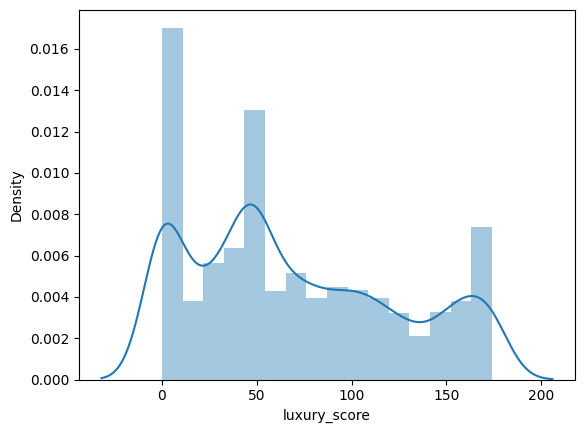

In [65]:
sns.distplot(df['luxury_score'])

<Axes: ylabel='luxury_score'>

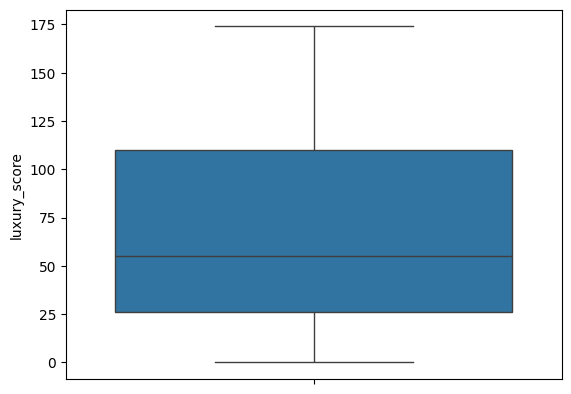

In [66]:
sns.boxplot(df['luxury_score'])

In [67]:
df.shape

(3590, 23)

In [68]:
df['price_per_sqft'] = round((df['price']*10000000)/df['area'])

In [69]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,house,signature global park,sohna road,0.85,7589.0,1120.0,Built Up area: 1120 (104.05 sq.m.),3.0,2.0,2.0,1.0,NaN,Under Construction,NaN,1120.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,15.0
1,flat,Conscient Heritage Max4.3 ★,sector 102,1.75,9063.0,1931.0,Super Built up area 1931(179.4 sq.m.),3.0,4.0,NaN,16.0,South,Relatively New,1931.0,NaN,NaN,0.0,1.0,0.0,0.0,0.0,1.0,134.0
3,flat,Alpha Corp GurgaonOne 844.0 ★,sector 84,2.24,6523.0,3434.0,Super Built up area 3434(319.03 sq.m.)Carpet a...,4.0,4.0,3.0,12.0,West,Relatively New,3434.0,NaN,2900.0,0.0,1.0,0.0,0.0,0.0,0.0,20.0
4,flat,Indiabulls Enigma,sector 110,3.40,10000.0,3400.0,Super Built up area 3400(315.87 sq.m.)Built Up...,4.0,5.0,3.0,10.0,South-West,Relatively New,3400.0,3000.0,2800.0,0.0,1.0,0.0,0.0,0.0,0.0,152.0
5,flat,Tulip Violet4.3 ★,sector 69,1.75,8883.0,1970.0,Super Built up area 1970(183.02 sq.m.),4.0,4.0,1.0,12.0,North-West,Relatively New,1970.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,86.0


/tmp/ipykernel_436/2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

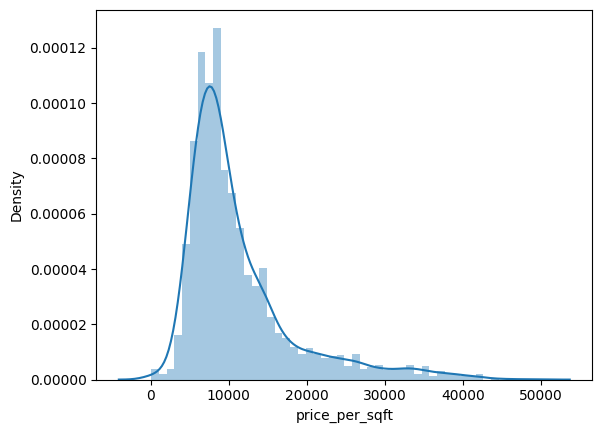

In [70]:
sns.distplot(df['price_per_sqft'])

<Axes: ylabel='price_per_sqft'>

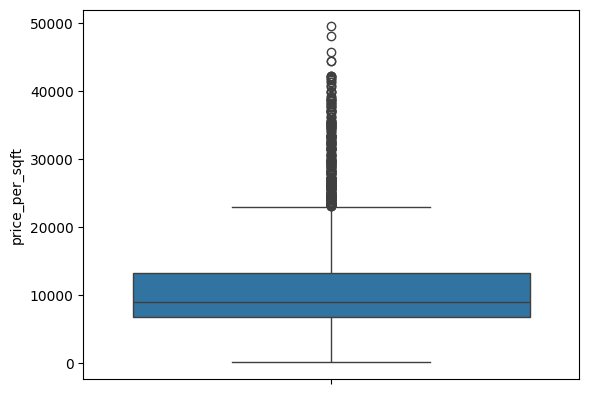

In [71]:
sns.boxplot(df['price_per_sqft'])

In [72]:
df[df['price_per_sqft'] > 42000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
322,house,dlf city plots,sector 26,19.0,42054.0,4518.0,Plot area 502(419.74 sq.m.),6.0,6.0,3.0,2.0,East,Relatively New,NaN,4518.0,NaN,1.0,1.0,0.0,0.0,0.0,1.0,121.0
1642,house,independent,sector 25,13.0,45710.0,2844.0,Plot area 316(264.22 sq.m.),6.0,8.0,NaN,NaN,NaN,Relatively New,NaN,2844.0,NaN,1.0,1.0,1.0,1.0,0.0,2.0,0.0
1915,house,independent,sector 43,9.5,42222.0,2250.0,Plot area 302(252.51 sq.m.)Built Up area: 300 ...,5.0,5.0,NaN,2.0,North-East,Relatively New,NaN,300.0,250.0,0.0,1.0,0.0,1.0,0.0,1.0,88.0
1974,house,independent,sector 26,20.0,44444.0,4500.0,Plot area 500(418.06 sq.m.),5.0,7.0,NaN,3.0,West,Relatively New,NaN,4500.0,NaN,0.0,1.0,0.0,1.0,0.0,2.0,97.0
2692,house,independent,sector 28,12.0,42194.0,2844.0,Plot area 316(264.22 sq.m.),4.0,5.0,NaN,4.0,East,Relatively New,NaN,2844.0,NaN,0.0,1.0,1.0,1.0,0.0,1.0,60.0
2809,house,independent,sector 105,9.9,49500.0,2000.0,Built Up area: 2000 (185.81 sq.m.)Carpet area:...,2.0,2.0,2.0,3.0,North,Undefined,NaN,2000.0,1800.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2906,house,independent,sector 55,5.0,44444.0,1125.0,Plot area 125(104.52 sq.m.)Built Up area: 115 ...,9.0,9.0,NaN,5.0,East,New Property,NaN,115.0,100.0,0.0,0.0,0.0,0.0,1.0,1.0,44.0
3002,house,sushant lok 1 builder floors,sector 43,13.0,48148.0,2700.0,Plot area 300(250.84 sq.m.),3.0,3.0,NaN,4.0,North,New Property,NaN,2700.0,NaN,0.0,0.0,0.0,1.0,0.0,1.0,7.0
3010,house,independent,sector 26,19.0,42222.0,4500.0,Plot area 500(418.06 sq.m.),6.0,8.0,NaN,3.0,East,Moderately Old,NaN,4500.0,NaN,1.0,1.0,1.0,1.0,0.0,1.0,103.0


In [73]:
x = df[df['price_per_sqft'] <= 20000]
(x['area']/x['bedRoom']).quantile(0.02)

np.float64(186.18)

In [74]:
df[(df['area']/df['bedRoom'])<183]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
15,house,sector 38 rwa,sector 38,1.40,23932.0,585.0,Plot area 65(54.35 sq.m.)Built Up area: 62 sq....,8.0,8.0,3.0,4.0,East,Moderately Old,NaN,62.0,60.0,0.0,0.0,0.0,0.0,1.0,1.0,40.0
134,house,prem kunj,sohna road road,0.50,7407.0,675.0,Plot area 675(62.71 sq.m.)Built Up area: 725 s...,5.0,4.0,3.0,3.0,South-West,Relatively New,NaN,725.0,675.0,0.0,0.0,0.0,1.0,0.0,0.0,22.0
188,house,independent,sohna road road,0.95,8920.0,1065.0,Plot area 1065(98.94 sq.m.),10.0,10.0,NaN,3.0,NaN,New Property,NaN,1065.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
264,house,independent,sector 104,0.60,5128.0,1170.0,Plot area 130(108.7 sq.m.),7.0,3.0,1.0,2.0,North,Moderately Old,NaN,1170.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
270,house,independent,sushant lok phase 2,1.45,26852.0,540.0,Plot area 60(5.57 sq.m.),4.0,4.0,NaN,4.0,East,Relatively New,NaN,60.0,NaN,0.0,0.0,1.0,0.0,0.0,0.0,70.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3392,house,my home,new sector 2,0.34,12593.0,270.0,Plot area 270(25.08 sq.m.),2.0,2.0,2.0,3.0,West,Moderately Old,NaN,270.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,22.0
3473,house,independent,sector 2,1.00,8230.0,1215.0,Plot area 135(112.88 sq.m.),9.0,7.0,NaN,3.0,North,Moderately Old,NaN,1215.0,NaN,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3530,house,independent,sector 2,3.65,23443.0,1557.0,Plot area 173(144.65 sq.m.),9.0,9.0,NaN,3.0,West,New Property,NaN,1557.0,NaN,0.0,1.0,0.0,1.0,0.0,1.0,116.0
3595,house,rajendra park gurgaon,sector 105,0.37,10278.0,360.0,Plot area 360(33.45 sq.m.),4.0,3.0,2.0,3.0,East,Relatively New,NaN,360.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [77]:
x = df[df['price_per_sqft'] <= 20000]

(x['area'] / x['bedRoom']).quantile(0.05)


np.float64(252.775)

In [79]:
df[df['area']/df['bedRoom']<250].sample(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2737,house,independent,sector 4,0.50,10482.0,477.0,Built Up area: 53 (44.31 sq.m.),5.0,3.0,NaN,1.0,NaN,Undefined,NaN,53.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
502,house,independent,sector 4,0.47,10609.0,443.0,Plot area 49(40.97 sq.m.)Built Up area: 50 sq....,2.0,2.0,1.0,2.0,East,New Property,NaN,50.0,48.000000,1.0,0.0,0.0,0.0,0.0,1.0,73.0
544,house,independent,sector 12,1.35,12217.0,1105.0,Plot area 150(125.42 sq.m.)Built Up area: 2052...,5.0,5.0,1.0,3.0,NaN,Old Property,NaN,2052.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,31.0
3135,house,independent,sector 6,0.50,13889.0,360.0,Plot area 40(33.45 sq.m.),5.0,3.0,3.0,3.0,NaN,Old Property,NaN,360.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1641,flat,MVN Athens3.7 ★,sohna road,0.27,5895.0,458.0,Carpet area: 457.81 (42.53 sq.m.),2.0,2.0,1.0,4.0,South-East,Relatively New,NaN,NaN,457.788667,0.0,0.0,0.0,0.0,1.0,1.0,35.0


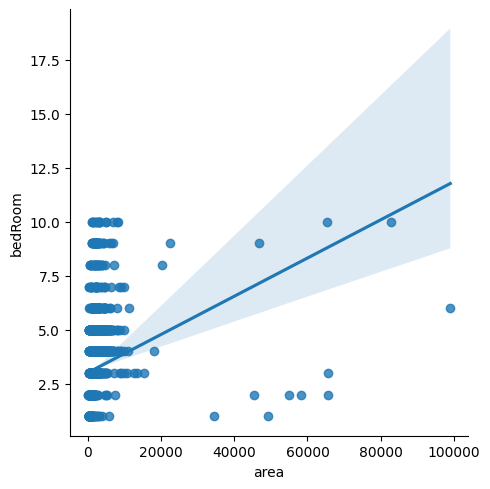

In [81]:
sns.lmplot(data=df, x='area', y='bedRoom')

In [83]:
df['area_room_ratio']=df['area']/df['bedRoom']

In [85]:
(df[df['area_room_ratio']<250])['bedRoom'].value_counts()

,count
bedRoom,
2.0,47
3.0,33
5.0,28
4.0,17
6.0,17
9.0,15
8.0,12
7.0,8
10.0,7


In [86]:
df= df[df['area_room_ratio']>100]

In [87]:
outlier_df=df[(df['area_room_ratio']<250)& (df['bedRoom']>3)]

In [88]:
outlier_df['bedRoom']=  round(outlier_df['bedRoom']/outlier_df['floorNum'])

/tmp/ipykernel_436/1494929160.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outlier_df['bedRoom']=  round(outlier_df['bedRoom']/outlier_df['floorNum'])


In [89]:
df.update(outlier_df)

In [90]:
df['area_room_ratio']= df['area']/df['bedRoom']

/tmp/ipykernel_436/1667099120.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['area_room_ratio']= df['area']/df['bedRoom']


In [91]:
df[(df['area_room_ratio']<250)& (df['bedRoom']>3)]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
560,house,independent,sector 3 phase 2,0.85,9444.0,900.0,Carpet area: 900 (83.61 sq.m.),5.0,3.0,3.0,1.0,NaN,Undefined,NaN,NaN,900.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,180.000000
1054,house,independent,sector 105,1.20,13333.0,900.0,Plot area 900(83.61 sq.m.),4.0,4.0,1.0,2.0,South-West,Moderately Old,NaN,900.0,NaN,0.0,0.0,0.0,0.0,1.0,0.0,14.0,225.000000
1135,house,surendra homes dayaindependentd colony,sector 6,0.75,15625.0,480.0,Built Up area: 480 (44.59 sq.m.),4.0,4.0,2.0,1.0,NaN,Undefined,NaN,480.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,120.000000
1414,house,independent,sector 2,0.98,9074.0,1080.0,Carpet area: 120 (100.34 sq.m.),9.0,4.0,3.0,1.0,South,Undefined,NaN,NaN,120.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,120.000000
1638,house,independent,sector 4,0.65,11111.0,585.0,Plot area 65(54.35 sq.m.),4.0,2.0,2.0,NaN,NaN,Moderately Old,NaN,585.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,146.250000
1680,house,independent,sector 3 phase 2,1.10,10000.0,1100.0,Built Up area: 1100 (102.19 sq.m.)Carpet area:...,5.0,4.0,2.0,1.0,East,Undefined,NaN,1100.0,900.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,220.000000
1888,house,independent,sector 12,0.65,6500.0,1000.0,Carpet area: 1000 (92.9 sq.m.),6.0,2.0,3.0,1.0,NaN,Undefined,NaN,NaN,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,166.666667
1901,house,independent,sector 3,0.92,15257.0,603.0,Built Up area: 603 (56.02 sq.m.),4.0,1.0,NaN,1.0,NaN,Undefined,NaN,603.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,150.750000
2642,house,independent,sector 105,1.10,12222.0,900.0,Carpet area: 900 (83.61 sq.m.),6.0,4.0,1.0,1.0,South-West,Undefined,NaN,NaN,900.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,150.000000
2649,house,"bhim nagar, sector 6",sector 6,0.85,14096.0,603.0,Plot area 67(6.22 sq.m.),5.0,2.0,2.0,1.0,NaN,Old Property,NaN,67.0,NaN,0.0,0.0,0.0,1.0,0.0,0.0,29.0,120.600000


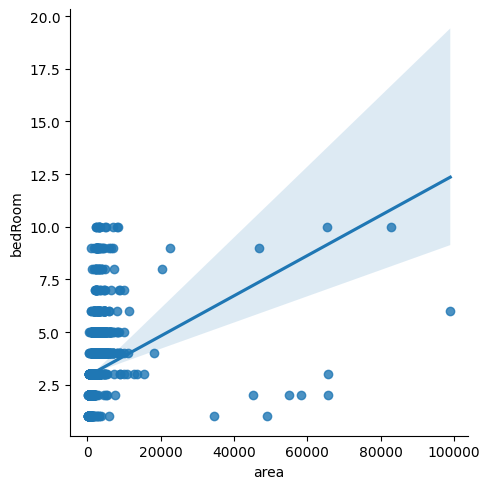

In [92]:
sns.lmplot(data=df, x='area', y='bedRoom')

In [93]:
df.shape

(3570, 24)

In [94]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
0,house,signature global park,sohna road,0.85,7589.0,1120.0,Built Up area: 1120 (104.05 sq.m.),3.0,2.0,2.0,1.0,NaN,Under Construction,NaN,1120.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,15.0,373.333333
1,flat,Conscient Heritage Max4.3 ★,sector 102,1.75,9063.0,1931.0,Super Built up area 1931(179.4 sq.m.),3.0,4.0,NaN,16.0,South,Relatively New,1931.0,NaN,NaN,0.0,1.0,0.0,0.0,0.0,1.0,134.0,643.666667
3,flat,Alpha Corp GurgaonOne 844.0 ★,sector 84,2.24,6523.0,3434.0,Super Built up area 3434(319.03 sq.m.)Carpet a...,4.0,4.0,3.0,12.0,West,Relatively New,3434.0,NaN,2900.0,0.0,1.0,0.0,0.0,0.0,0.0,20.0,858.500000
4,flat,Indiabulls Enigma,sector 110,3.40,10000.0,3400.0,Super Built up area 3400(315.87 sq.m.)Built Up...,4.0,5.0,3.0,10.0,South-West,Relatively New,3400.0,3000.0,2800.0,0.0,1.0,0.0,0.0,0.0,0.0,152.0,850.000000
5,flat,Tulip Violet4.3 ★,sector 69,1.75,8883.0,1970.0,Super Built up area 1970(183.02 sq.m.),4.0,4.0,1.0,12.0,North-West,Relatively New,1970.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,86.0,492.500000


In [95]:
df.to_csv('gurgaon_properties_outlier_treated.csv', index=False)